In [1]:
import lightgbm as lgb
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import polars as pl
import numpy as np
import optuna

In [2]:
from pathlib import Path
path = Path.cwd()
if not Path(path, "data").exists(): path = path.parent

In [3]:
df_train = pl.read_parquet(path / "data" / "train_tip.parquet")
df_val = pl.read_parquet(path / "data" / "val_tip.parquet")
df_test = pl.read_parquet(path / "data" / "test_tip.parquet")

In [4]:
categorical_cols = ["payment_type", "VendorID", "weekday", "month", 'PULocationID', 'DOLocationID']
input_cols = [col for col in df_train.columns if col not in ['tip_amount']]

x_train, y_train = df_train.select(input_cols), df_train.select("tip_amount").to_numpy()
x_test, y_test = df_test.select(input_cols), df_test.select("tip_amount").to_numpy()
x_val, y_val = df_val.select(input_cols), df_val.select("tip_amount").to_numpy()

## Prueba con rmse

In [5]:
train_data = lgb.Dataset(
    data=x_train, 
    label=y_train, 
    feature_name=input_cols,
    categorical_feature=categorical_cols,
    free_raw_data=False
)

val_data = lgb.Dataset(
    data=x_val, 
    label=y_val, 
    reference=train_data,
    feature_name=input_cols
)

lgbm_params = {
    'objective': 'tweedie',
    'boosting': 'gbdt',
    'max_bin': 255,
    'metric': 'rmse',
    'verbose': -1,
    'tweedie_variance_power': 1.5736005740734198,
    'learning_rate': 0.10469439266335008,
    'num_leaves': 268,
    'max_depth': 12,
    'min_data_in_leaf': 702,
    'feature_fraction': 0.6035669550945819,
    'bagging_fraction': 0.979833460020387,
    'bagging_freq': 4,
}

model_lgb = lgb.train(
    params=lgbm_params,
    train_set=train_data,
    num_boost_round=5000,
    valid_sets=[train_data, val_data],
    valid_names=['Entrenamiento', 'Validacion'],
    
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")


Training until validation scores don't improve for 50 rounds
[100]	Entrenamiento's rmse: 261.585	Validacion's rmse: 275.029
[200]	Entrenamiento's rmse: 260.834	Validacion's rmse: 274.933
Early stopping, best iteration is:
[196]	Entrenamiento's rmse: 260.842	Validacion's rmse: 274.932


In [6]:
model_lgb.save_model(path / "data" / "lgbm_rmse274.932_train_tip.txt")

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

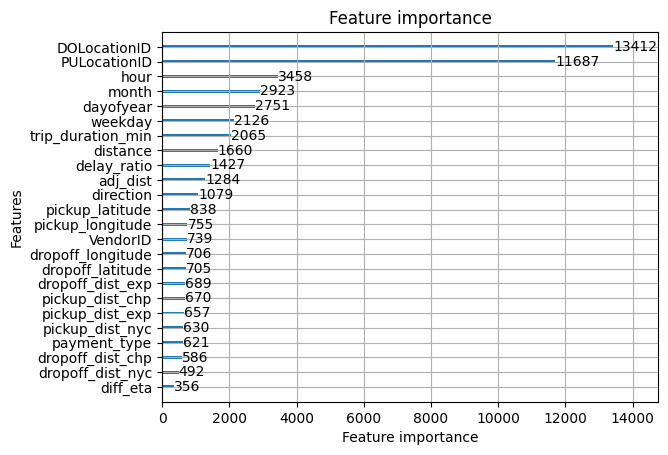

In [7]:
lgb.plot_importance(model_lgb)

Prácticamente está agrupando por locationID y prediciendo la media.

In [8]:
def evaluar_modelo(y_true, y_pred, nombre_set="Test"):
    """
    Evalúa predicciones de regresión y devuelve un diccionario con las métricas.
    Soporta entradas como Series de Polars, listas o arrays de NumPy.
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    media_real = np.mean(y_true)
    media_pred = np.mean(y_pred)
    
    print(f"\n--- REPORTE DE RENDIMIENTO: {nombre_set} ---")
    print(f"MAE  (Error Absoluto Medio):       {mae:.4f}")
    print(f"RMSE (Raíz del Error Cuadrático):  {rmse:.4f}")
    print(f"R²   (Coef. de Determinación):     {r2:.4f}")
    print("-" * 45)
    print(f"Propina media real del set:        {media_real:.4f}")
    print(f"Propina media predicha:            {media_pred:.4f}")
    print("-" * 45)
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Media_Real": media_real,
        "Media_Pred": media_pred
    }

predicciones = model_lgb.predict(x_test)
metricas_finales = evaluar_modelo(y_test, predicciones, nombre_set="Test (Nov-Dic 2025) num optuna")

c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")



--- REPORTE DE RENDIMIENTO: Test (Nov-Dic 2025) num optuna ---
MAE  (Error Absoluto Medio):       155.5616
RMSE (Raíz del Error Cuadrático):  292.7058
R²   (Coef. de Determinación):     0.1546
---------------------------------------------
Propina media real del set:        112.4857
Propina media predicha:            97.5584
---------------------------------------------


## Entrenamiento con huber

In [13]:
train_data = lgb.Dataset(
    data=x_train, 
    label=y_train, 
    feature_name=input_cols,
    categorical_feature=categorical_cols,
    free_raw_data=False
)

val_data = lgb.Dataset(
    data=x_val, 
    label=y_val, 
    reference=train_data,
    feature_name=input_cols
)

lgbm_params = {
    'objective': 'tweedie',
    'boosting': 'gbdt',
    'max_bin': 255,
    'metric': 'huber',
    'verbose': -1,
    'tweedie_variance_power': 1.5736005740734198,
    'learning_rate': 0.010469439266335008,
    'num_leaves': 268,
    'max_depth': 12,
    'min_data_in_leaf': 702,
    'feature_fraction': 0.6035669550945819,
    'bagging_fraction': 0.979833460020387,
    'bagging_freq': 4,
}

model_lgb = lgb.train(
    params=lgbm_params,
    train_set=train_data,
    num_boost_round=5000,
    valid_sets=[train_data, val_data],
    valid_names=['Entrenamiento', 'Validacion'],
    
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, first_metric_only=False, verbose=True),
        lgb.log_evaluation(period=50)
    ]
) # huber

Training until validation scores don't improve for 100 rounds
[50]	Entrenamiento's huber: 158.228	Validacion's huber: 162.493
[100]	Entrenamiento's huber: 147.569	Validacion's huber: 151.576
[150]	Entrenamiento's huber: 141.11	Validacion's huber: 144.833
[200]	Entrenamiento's huber: 137.338	Validacion's huber: 140.91
[250]	Entrenamiento's huber: 134.897	Validacion's huber: 138.413
[300]	Entrenamiento's huber: 133.279	Validacion's huber: 136.737
[350]	Entrenamiento's huber: 132.277	Validacion's huber: 135.724
[400]	Entrenamiento's huber: 131.6	Validacion's huber: 135.045
[450]	Entrenamiento's huber: 131.138	Validacion's huber: 134.55
[500]	Entrenamiento's huber: 130.849	Validacion's huber: 134.238
[550]	Entrenamiento's huber: 130.626	Validacion's huber: 133.995
[600]	Entrenamiento's huber: 130.465	Validacion's huber: 133.827
[650]	Entrenamiento's huber: 130.352	Validacion's huber: 133.712
[700]	Entrenamiento's huber: 130.256	Validacion's huber: 133.607
[750]	Entrenamiento's huber: 130.1

In [14]:
predicciones = model_lgb.predict(x_test)
metricas_finales = evaluar_modelo(y_test, predicciones, nombre_set="Test (Nov-Dic 2025) num optuna")

c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")



--- REPORTE DE RENDIMIENTO: Test (Nov-Dic 2025) num optuna ---
MAE  (Error Absoluto Medio):       154.4770
RMSE (Raíz del Error Cuadrático):  292.6814
R²   (Coef. de Determinación):     0.1548
---------------------------------------------
Propina media real del set:        112.4857
Propina media predicha:            96.0800
---------------------------------------------


Prácticamente el mismo resultado.